# Лабораторная работа 7

Тема: **Многослойный персептрон для табличных данных (полный цикл: предобработка → PyTorch → анализ)**  
Цель: на табличном датасете с числовыми и категориальными признаками пройти все этапы: подготовка данных, построение MLP в PyTorch, обучение, оценка и осмысленная интерпретация результатов.

> Этот ноутбук не предназначен для автоматического заполнения текстом из генеративных моделей.  
> Большая часть баллов ставится за то, **как вы сами объясняете** сделанные шаги и комментируете свои эксперименты.  
> Код можно использовать как каркас, но текстовые ответы и выбор настроек должны быть вашими.


## 1. Ваше понимание задачи (коротко)

Перед тем как писать код, сформулируйте для себя:

1. Чем, на ваш взгляд, работа с табличными данными отличается от работы с картинками (MNIST) в предыдущих работах?  
2. Какие сложности добавляет наличие одновременно числовых и категориальных признаков?  
3. Зачем в такой задаче может понадобиться нейросеть, если у нас есть логистическая регрессия, деревья решений и т.п.?

Напишите 5–8 предложений **на своём языке**, без попытки выдать энциклопедическое определение.


In [23]:
intro_text = """
1) В MNIST признаки одинаковые - это значения пикселей изображения.
В табличных данных признаки разные: возраст, зарплата, рост и тд. Это разные единицы измерения.
А MLP не умеет работать со строками, поэтому нужен перевод в числа.
2) Категориальные признаки нужно сначала преобразовать в числовой вид, а числовые нужно масщтабировать, чтобы большие значения не доминировали над остальными.
3) Логистическая регрессия работает, когда решение можно принять по относительно простым правилам, 
например, вероятность покупки товара зависит от возраста и дохода клиента. 
Деревья решений умеют строить последовательности, например:
если возраст меньше 18 -> не купит;
если возраст больше или равно 18 и доход больше 50 000 -> купит;
если возраст больше или равно 18 и доход меньше или равно 50 000 -> не купит.
Нейросеть полезна, когда зависимость гораздо сложнее. Например, покупка зависит от возраста, дохода, региона, семейного положения и тд.
В таком случае нейросеть способна самостоятельно находить сложные взаимосвязи между признаками.
"""
print(intro_text)


1) В MNIST признаки одинаковые - это значения пикселей изображения.
В табличных данных признаки разные: возраст, зарплата, рост и тд. Это разные единицы измерения.
А MLP не умеет работать со строками, поэтому нужен перевод в числа.
2) Категориальные признаки нужно сначала преобразовать в числовой вид, а числовые нужно масщтабировать, чтобы большие значения не доминировали над остальными.
3) Логистическая регрессия работает, когда решение можно принять по относительно простым правилам, 
например, вероятность покупки товара зависит от возраста и дохода клиента. 
Деревья решений умеют строить последовательности, например:
если возраст меньше 18 -> не купит;
если возраст больше или равно 18 и доход больше 50 000 -> купит;
если возраст больше или равно 18 и доход меньше или равно 50 000 -> не купит.
Нейросеть полезна, когда зависимость гораздо сложнее. Например, покупка зависит от возраста, дохода, региона, семейного положения и тд.
В таком случае нейросеть способна самостоятельно находить

## 2. Импорт библиотек и настройка среды

В этом блоке:
- импортируем базовые библиотеки для работы с табличными данными (`pandas`, `sklearn`),
- импортируем PyTorch и инструменты для обучения,
- фиксируем зерно случайности (одно число),
- определяем устройство (`cpu` / `cuda`).


In [7]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

# Ваш seed (выберите сами и используйте последовательно)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Табличные данные: генерация и первичный осмотр

Для этой лабораторной можно брать реальный CSV‑файл, но чтобы не зависеть от внешних данных, здесь используется синтетический пример.

Шаги:
- сгенерировать датасет с помощью `make_classification` (бинарная классификация);
- обернуть в `pandas.DataFrame` и добавить одну простую категориальную колонку;
- посмотреть на первые строки и распределение целевой переменной.


In [8]:
X, y = make_classification(
    n_samples=8000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    random_state=MY_SEED
)

df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df["target"] = y

# Простейшая категориальная фича на основе порога по одному из признаков
df["cat_col"] = np.where(df["feat_0"] > 0, "high", "low")

print(df.head())
print("Форма датафрейма:", df.shape)
print("Распределение классов (доля):\n", df["target"].value_counts(normalize=True))

     feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0  1.614925 -0.958699  1.936482 -0.615358  1.802333  1.621273 -1.241060   
1 -1.583122  1.774321 -0.868924 -1.012061  0.838906 -1.312666 -1.103179   
2 -0.097246 -3.473297  0.130644  0.409553  1.193109 -1.160431 -1.017802   
3 -1.563796 -1.962565 -1.849396 -0.143836  1.368490 -2.368872  0.431229   
4 -1.842540 -0.108332 -0.282043 -0.208419  0.877210  0.800632 -1.149481   

     feat_7  target cat_col  
0  1.151897       0    high  
1 -1.711924       0     low  
2  2.728710       0     low  
3  0.645494       1     low  
4  2.488247       0     low  
Форма датафрейма: (8000, 10)
Распределение классов (доля):
 target
0    0.500875
1    0.499125
Name: proportion, dtype: float64


Отделим списки числовых и категориальных колонок и целевую переменную.  
Это пригодится при предобработке.


In [9]:
numeric_cols = [c for c in df.columns if c.startswith("feat_")]
cat_cols = ["cat_col"]
target_col = "target"

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7']
Категориальные признаки: ['cat_col']


## 4. Разбиение на train/val/test и предобработка

Мы не хотим использовать тестовую выборку при подборе гиперпараметров, поэтому разделим данные в два этапа:
- train + временный остаток (val+test);
- остаток → val + test.

Числовые признаки будем масштабировать (`StandardScaler`), категориальные — кодировать через `OneHotEncoder`.  
Важно: все преобразования обучаются **только на train**, затем применяются к val и test.


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=MY_SEED,
    stratify=df[target_col]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=MY_SEED,
    stratify=temp_df[target_col]
)

print("Размер train:", train_df.shape)
print("Размер val  :", val_df.shape)
print("Размер test :", test_df.shape)

Размер train: (5600, 10)
Размер val  : (1200, 10)
Размер test : (1200, 10)


In [11]:
scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# обучаем только на train
scaler.fit(train_df[numeric_cols])
encoder.fit(train_df[cat_cols])

def transform_df(df_part):
    X_num = scaler.transform(df_part[numeric_cols])
    X_cat = encoder.transform(df_part[cat_cols])
    X_all = np.hstack([X_num, X_cat])
    y_all = df_part[target_col].values.astype(np.int64)
    return X_all, y_all

X_train, y_train = transform_df(train_df)
X_val, y_val = transform_df(val_df)
X_test, y_test = transform_df(test_df)

print("Форма X_train:", X_train.shape)
print("Форма X_val  :", X_val.shape)
print("Форма X_test :", X_test.shape)
print("Кол-во классов в train:", np.bincount(y_train))

Форма X_train: (5600, 10)
Форма X_val  : (1200, 10)
Форма X_test : (1200, 10)
Кол-во классов в train: [2805 2795]


### Ваш короткий комментарий по данным

Здесь полезно в 3–5 предложениях описать:
- выглядят ли классы примерно сбалансированными;
- нет ли подозрений на слишком лёгкую/сложную задачу, исходя из числа признаков и информативности;
- как вы ожидаете, будет вести себя простая линейная модель на этих данных.


In [15]:
data_comment = """
Классы распределены почти равномерно 0.50 и 0.49.
Размер датасета достаточно большой для обучения модели, а число признаков не слишком велико.
На первый взгляд задача не выглядит ни слишком простой, ни слишком сложной.
Из 8 признаков только 5 информативных, 1 избыточный, 2 шум - это реалистично.
"""
print(data_comment)


Классы распределены почти равномерно 0.50 и 0.49.
Размер датасета достаточно большой для обучения модели, а число признаков не слишком велико.
На первый взгляд задача не выглядит ни слишком простой, ни слишком сложной.
Из 8 признаков только 5 информативных, 1 избыточный, 2 шум - это реалистично.



## 5. Dataset и DataLoader для табличных данных

Опишем класс `TabularDataset`, который превращает массивы NumPy в тензоры PyTorch, и создадим `DataLoader` для train/val/test.


In [14]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# выберите batch_size, который вам комфортен (обоснуйте это позже)
batch_size = 128 # 5600 / 128 ≈ 44 шага за эпоху - разумный баланс
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 44


## 6. Архитектура MLP для табличных данных

Теперь опишем саму сеть.  
Требования к базовому варианту:
- входной размер = число столбцов в `X_train`;
- 1–2 скрытых слоя с нелинейностью (ReLU или другая на ваш выбор);
- выходной слой из 2 нейронов (для двух классов), без Softmax.

Параметры (размеры слоёв) выбирайте так, чтобы модель не была ни слишком крошечной, ни чрезмерно большой.


In [16]:
input_dim = X_train.shape[1]
hidden_dim1 = 64
hidden_dim2 = 32
output_dim = 2
print(f"Архитектура: {input_dim} -> {hidden_dim1} -> {hidden_dim2} -> {output_dim}")

class TabularMLP(nn.Module):
    def __init__(self, in_features, h1, h2, out_features):
        super().__init__()
        self.net = nn.Sequential(
            # Слой 1
            nn.Linear(in_features, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Слой 2
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Выходной слой
            nn.Linear(h2, out_features)
        )

    def forward(self, x):
        return self.net(x)

model = TabularMLP(input_dim, hidden_dim1, hidden_dim2, output_dim).to(device)
print(model)

Архитектура: 10 -> 64 -> 32 -> 2
TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)


Выберите функцию потерь и оптимизатор. Для данной задачи подойдёт:
- `nn.CrossEntropyLoss` для потерь;
- любой из стандартных оптимизаторов (`Adam`, `SGD`, `AdamW`...) с осмысленным `learning_rate`.


In [18]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3 # 0.001 - стандарт для Adam (из ЛР6: самый быстрый и стабильный)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


## 7. Цикл обучения и валидации

Реализуем стандартные функции:
- `train_one_epoch` — один проход по train,
- `evaluate` — расчёт loss и accuracy на val или test.

Затем запустим обучение на несколько эпох, сохраняя историю метрик для визуализации.


In [19]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [20]:
num_epochs = 30
# 30 эпох: на MNIST хватало 8-10 (938 шагов/эпоха).
# Здесь только 44 шага/эпоха - нужно больше эпох чтобы увидеть ту же динамику.
# 30*44 = 1320 шагов оптимизатора - сопоставимо с 1-2 эпохами на MNIST.

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/30 | train_loss=0.6081, train_acc=0.6720, val_loss=0.4700, val_acc=0.8350
Эпоха 2/30 | train_loss=0.4662, train_acc=0.7927, val_loss=0.3595, val_acc=0.8592
Эпоха 3/30 | train_loss=0.4008, train_acc=0.8223, val_loss=0.3180, val_acc=0.8650
Эпоха 4/30 | train_loss=0.3694, train_acc=0.8377, val_loss=0.2928, val_acc=0.8733
Эпоха 5/30 | train_loss=0.3448, train_acc=0.8479, val_loss=0.2749, val_acc=0.8825
Эпоха 6/30 | train_loss=0.3274, train_acc=0.8548, val_loss=0.2636, val_acc=0.8867
Эпоха 7/30 | train_loss=0.3175, train_acc=0.8580, val_loss=0.2531, val_acc=0.8958
Эпоха 8/30 | train_loss=0.3113, train_acc=0.8655, val_loss=0.2440, val_acc=0.8992
Эпоха 9/30 | train_loss=0.3111, train_acc=0.8641, val_loss=0.2373, val_acc=0.9008
Эпоха 10/30 | train_loss=0.2832, train_acc=0.8766, val_loss=0.2325, val_acc=0.8983
Эпоха 11/30 | train_loss=0.2875, train_acc=0.8743, val_loss=0.2233, val_acc=0.9008
Эпоха 12/30 | train_loss=0.2908, train_acc=0.8736, val_loss=0.2198, val_acc=0.9067
Эпоха 13/30 |

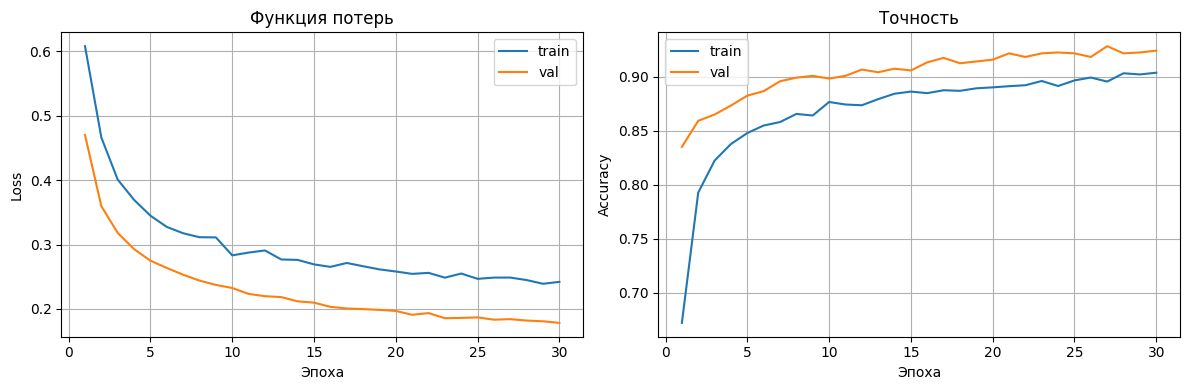

Финальное качество: train_acc=0.9038, val_acc=0.9242


In [21]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальное качество: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Кратко опишите (6–8 предложений):
- есть ли разрыв между train и val accuracy;
- видно ли переобучение (train растёт, val падает или стагнирует);
- насколько выбранные `num_epochs` и `learning_rate` кажутся вам удачными.

Привязывайтесь к конкретным числам (например, точности на первой и последней эпохах).


In [24]:
training_comment = """
1) На протяжении всего обучения val_acc была выше train_acc. 
Например, на 1 эпохе: train=0.6720, val=0.8350, а на 30: train=0.9038, val=0.9242. 
Это нормально для Dropout: во время обучения часть нейронов отключается, поэтому train_acc получается ниже.

2) Переобучения не видно. val_loss стабильно снижался с 0.4700 до 0.1783 без заметных скачков вверх. 
BatchNorm и Dropout хорошо справились со своей задачей.

3) 30 эпох оказались удачными: к эпохе 21 val_acc достиг 0.9217,а к 30 подрос до 0.9242, рост небольшой, но ещё шёл. Можно было взять чуть больше.
При lr=0.001 кривые без резких скачков, равномерное падение loss. Из ЛР 6: для Adam именно 0.001 - оптимальный стандарт, здесь это подтвердилось.
"""
print(training_comment)



1) На протяжении всего обучения val_acc была выше train_acc. 
Например, на 1 эпохе: train=0.6720, val=0.8350, а на 30: train=0.9038, val=0.9242. 
Это нормально для Dropout: во время обучения часть нейронов отключается, поэтому train_acc получается ниже.

2) Переобучения не видно. val_loss стабильно снижался с 0.4700 до 0.1783 без заметных скачков вверх. 
BatchNorm и Dropout хорошо справились со своей задачей.

3) 30 эпох оказались удачными: к эпохе 21 val_acc достиг 0.9217,а к 30 подрос до 0.9242, рост небольшой, но ещё шёл. Можно было взять чуть больше.
При lr=0.001 кривые без резких скачков, равномерное падение loss. Из ЛР 6: для Adam именно 0.001 - оптимальный стандарт, здесь это подтвердилось.



## 8. Оценка на тестовой выборке

Теперь посмотрим, как модель работает на отложенном тестовом множестве, которое мы ещё ни разу не использовали при обучении и настройке гиперпараметров.


In [22]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=0.1720, accuracy=0.9317


### (Опционально) Примеры ошибок и дополнительные метрики

Если хотите, можете:
- собрать предсказания на test и посчитать матрицу ошибок (`confusion_matrix` из `sklearn`);
- посмотреть, какие объекты модель чаще всего классифицирует неверно;
- сравнить качество MLP с простой базовой моделью (например, логистической регрессией).

Эта часть не обязательна, но полезна для более глубокого понимания.


## 9. Итоговые выводы по вашей будущей работе

В своей версии лабораторной вы будете использовать **свой** датасет и, возможно, другие настройки.  
Здесь сформулируйте общие выводы о том, что вам кажется важным при работе с табличными данными и MLP:

- какие шаги предобработки оказались принципиальными (масштабирование, кодирование категорий и т.п.);
- насколько чувствительной к этим шагам показалась вам модель;
- где, на ваш взгляд, MLP может выигрывать у линейных моделей, а где — нет.

Пишите как для будущего себя, который откроет этот ноутбук через полгода и захочет вспомнить, что здесь происходило.


In [25]:
final_reflection = """
1) В этой работе BatchNorm и Dropout позволили обучать модель 30 эпох без признаков переобучения: 
val_loss снизился с 0.4700 до 0.1783 и ни разу не начал расти. 
В прошлой работе базовая модель без регуляризации начинала переобучаться уже к 4–5 эпохе.
Из предобработки обязательными были StandardScaler и кодирование категориального признака. 
Без них данные просто нельзя было бы корректно подать в MLP.

2) По результатам экспериментов видно, что модель довольно чувствительна к настройкам. 
Например, в прошлой работе слишком большой Dropout (p=0.7) снизил test_acc до 0.9636, тогда как p=0.2 дал 0.9803. 
Здесь также хорошо видно влияние регуляризации: благодаря BatchNorm и Dropout за 30 эпох val_loss снизился с 0.4700 до 0.1783 и переобучения не появилось. 
В конце удалось получить val_acc=0.9242 и test_acc=0.9317.

3) По результатам этой работы видно, что MLP может хорошо работать с табличными данными. 
В моём случае удалось получить test_acc=0.9317, а благодаря BatchNorm и Dropout модель не переобучилась даже за 30 эпох.
Однако больше не всегда значит лучше. Например в прошлой работе LargeMLP получила test_acc=0.9770, а BaseMLP test_acc=0.9785. 
То есть увеличение числа параметров не дало улучшения качества.
Поэтому я бы использовала MLP когда есть основания считать, что между признаками существуют сложные взаимосвязи. 
"""
print(final_reflection)



1) В этой работе BatchNorm и Dropout позволили обучать модель 30 эпох без признаков переобучения: 
val_loss снизился с 0.4700 до 0.1783 и ни разу не начал расти. 
В прошлой работе базовая модель без регуляризации начинала переобучаться уже к 4–5 эпохе.
Из предобработки обязательными были StandardScaler и кодирование категориального признака. 
Без них данные просто нельзя было бы корректно подать в MLP.

2) По результатам экспериментов видно, что модель довольно чувствительна к настройкам. 
Например, в прошлой работе слишком большой Dropout (p=0.7) снизил test_acc до 0.9636, тогда как p=0.2 дал 0.9803. 
Здесь также хорошо видно влияние регуляризации: благодаря BatchNorm и Dropout за 30 эпох val_loss снизился с 0.4700 до 0.1783 и переобучения не появилось. 
В конце удалось получить val_acc=0.9242 и test_acc=0.9317.

3) По результатам этой работы видно, что MLP может хорошо работать с табличными данными. 
В моём случае удалось получить test_acc=0.9317, а благодаря BatchNorm и Dropout мод